In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [2]:
df_train=pd.read_csv('../input/titanic/train.csv')
df1=df_train

In [3]:
df_test=pd.read_csv('../input/titanic/test.csv')
df2=df_test

In [4]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df1.shape

(891, 12)

In [7]:
df2.shape

(418, 11)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [10]:
df1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df2.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
df1.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
df2.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
df1.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df2.drop(columns= ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace= True)

In [15]:
df1['Age'].fillna(df1['Age'].median(), inplace=True)
df1['Embarked'].fillna(df1['Embarked'].mode()[0], inplace=True)

In [16]:
df2['Age'].fillna(df2['Age'].median(), inplace=True)
df2['Fare'].fillna(df2['Fare'].median(), inplace=True)

There are no null values in test dataset anymore.



In [17]:
df1['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [18]:
df1['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [19]:
df2['Pclass'].value_counts()

3    218
1    107
2     93
Name: Pclass, dtype: int64

In [20]:
df2['Sex'].value_counts()


male      266
female    152
Name: Sex, dtype: int64

In [21]:
df2['SibSp'].value_counts()


0    283
1    110
2     14
4      4
3      4
8      2
5      1
Name: SibSp, dtype: int64

Visualisation

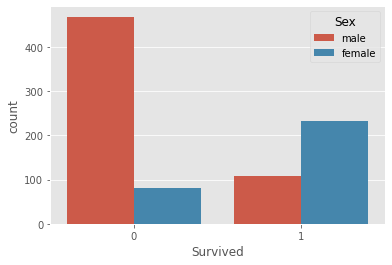

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data= df1)

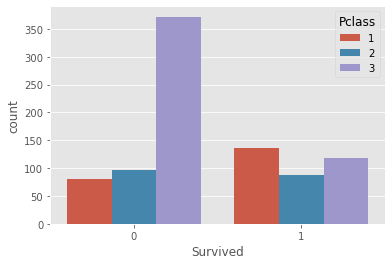

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Pclass', data= df1)

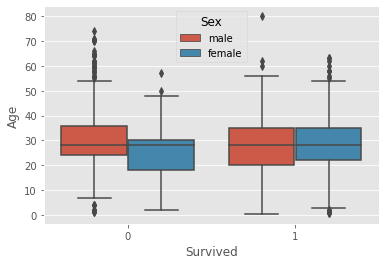

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived',y='Age',hue='Sex',data=df1)

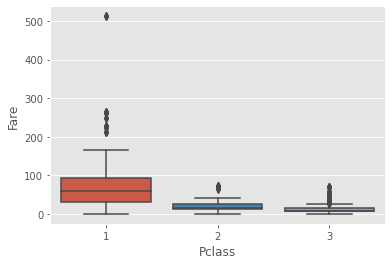

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pclass', y= 'Fare', data= df1)

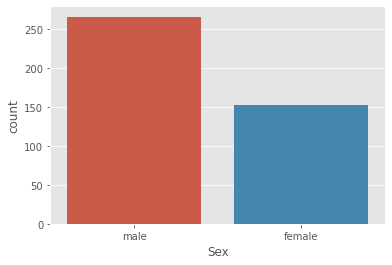

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data= df2)

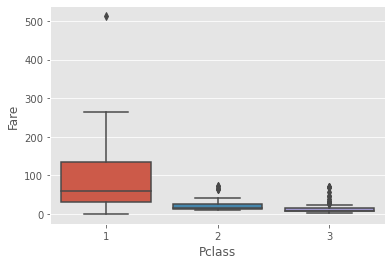

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pclass', y= 'Fare', data= df2)

Detecting outliers

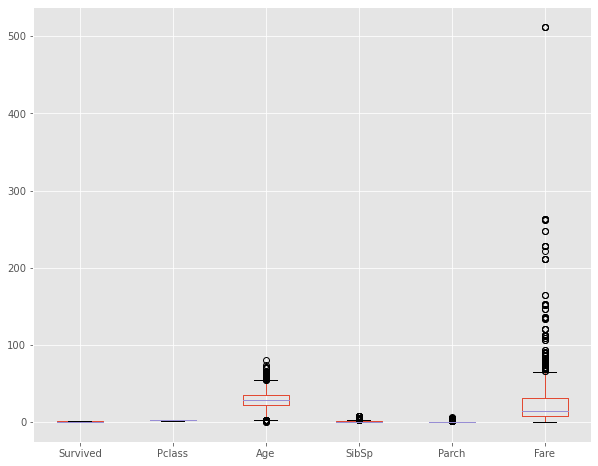

In [28]:
df1.plot(kind='box', figsize= (10,8))


In [29]:
lst= ['Age', 'SibSp', 'Parch', 'Fare']

df1[lst]= df1[lst].clip(lower= df1[lst].quantile(0.15), upper= df1[lst].quantile(0.85), axis=1)
df1.drop(columns=['Parch'], axis=1, inplace=True)



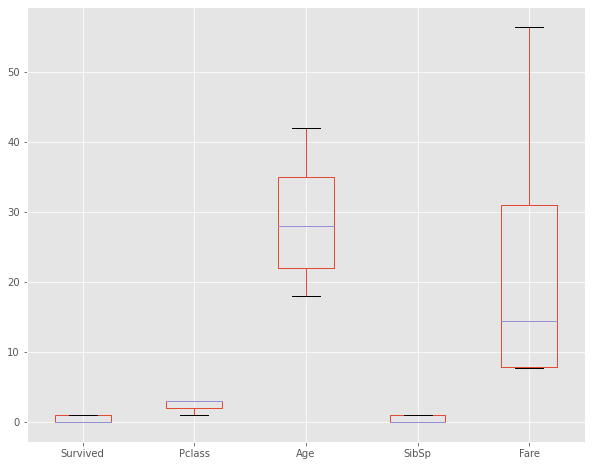

In [30]:
df1.plot(kind='box', figsize= (10,8))


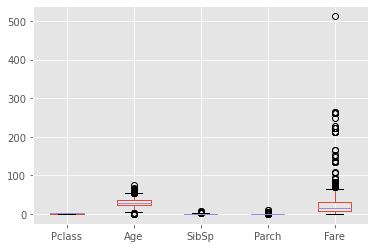

In [31]:
df2.plot(kind='box', figsize=(6,4))

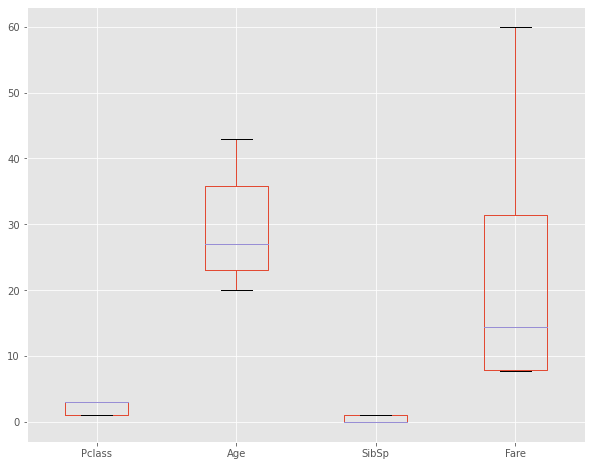

In [32]:
df2[lst]= df2[lst].clip(lower= df2[lst].quantile(0.15), upper= df2[lst].quantile(0.85), axis=1)
df2.drop(columns=['Parch'], axis=1, inplace=True)
df2.plot(kind='box', figsize= (10,8))  